# Code for the ARI5121 (Speech) Assignment

Using Microsoft WavLM's model model speaker voice similarity.

Resource (and references):
- WavLM HuggingFace: https://huggingface.co/microsoft/wavlm-base-plus-sv
- papers/*

## Imports

Import any libraries required.

In [1]:
import os
from itertools import combinations
from collections import Counter, defaultdict

import seaborn as sns
import sounddevice as sd
import numpy as np
import matplotlib.pyplot as plt
import torch
import librosa
from transformers import (
    Wav2Vec2FeatureExtractor,
    WavLMForXVector
)
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

## Attributes

Define any common attributes.

In [2]:
datasets_base_dir = "datasets"

# load feature extractor
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained('microsoft/wavlm-base-plus-sv')

# load model
# we use the 'WavLMForXVector' class instead of the 'WavLMModel' class on purpose
# the 'WavLMForXVector' adds a pooling layer automatically on top of the 'WavLM' model
# hence, we won't need to apply pooling afterwards
model = WavLMForXVector.from_pretrained('microsoft/wavlm-base-plus-sv')

# set inference mode instead of training mode
model.eval()

# embeddings file so we create embeddings only once
EMBEDDINGS_FILE = "embeddings.pt"
COMPARISONS_FILE = "comparisons.pt"

Loading weights:   0%|          | 0/266 [00:00<?, ?it/s]

## Initial Experimentation

Loading one WAV file from the corpus and getting it's audio/sample rate.

Discovery: Sample is 22kHz but WavLM requires 16kHz (as mentioned in the HuggingFace docs).

In [3]:
experiment_wav_file = f"{datasets_base_dir}/abi-1-corpus/accents/brm_001/female/alw001/shortpassagea_CT.wav"
audio, sample_rate = librosa.load(experiment_wav_file)

print(f"Sample rate: {sample_rate} Hz")
print(f"Duration: {len(audio)/sample_rate:.2f}s")
print(f"Shape: {audio.shape}")

Sample rate: 22050 Hz
Duration: 49.62s
Shape: (1094132,)


In [4]:
audio, sample_rate = librosa.load(experiment_wav_file, sr=16000)

print(f"Sample rate: {sample_rate} Hz")
print(f"Duration: {len(audio)/sample_rate:.2f}s")
print(f"Shape: {audio.shape}")

Sample rate: 16000 Hz
Duration: 49.62s
Shape: (793928,)


### Pre-processing

Two pre-processing steps to do:

1. Silence removal (noticed that after listening through some .wav files sometimes there are small pauses in between sentences).
2. Normalise so that max. amplitude of the waveform is between ±1.

It's important that we first do silence removal because normalisation scales the waveform based on it's loudest sample and this might affect silence removal (as silence/background noise in the audio would be also normalised).

#### Silence removal

Experiment with different rates of `top_db` values. `top_db` represents top decibels. For example, if we choose a `top_db` value of 30, if at any point in the file there is audio that is less than 30 decibels from the max, then this is considered as silent and trimmed.

Discovery: After experimentation, it seems that a `top_db` value of between 30 is ideal as can be seen in the graph below. To double check, we also play the sound of the trimmed audio to make sure that everything is okay.

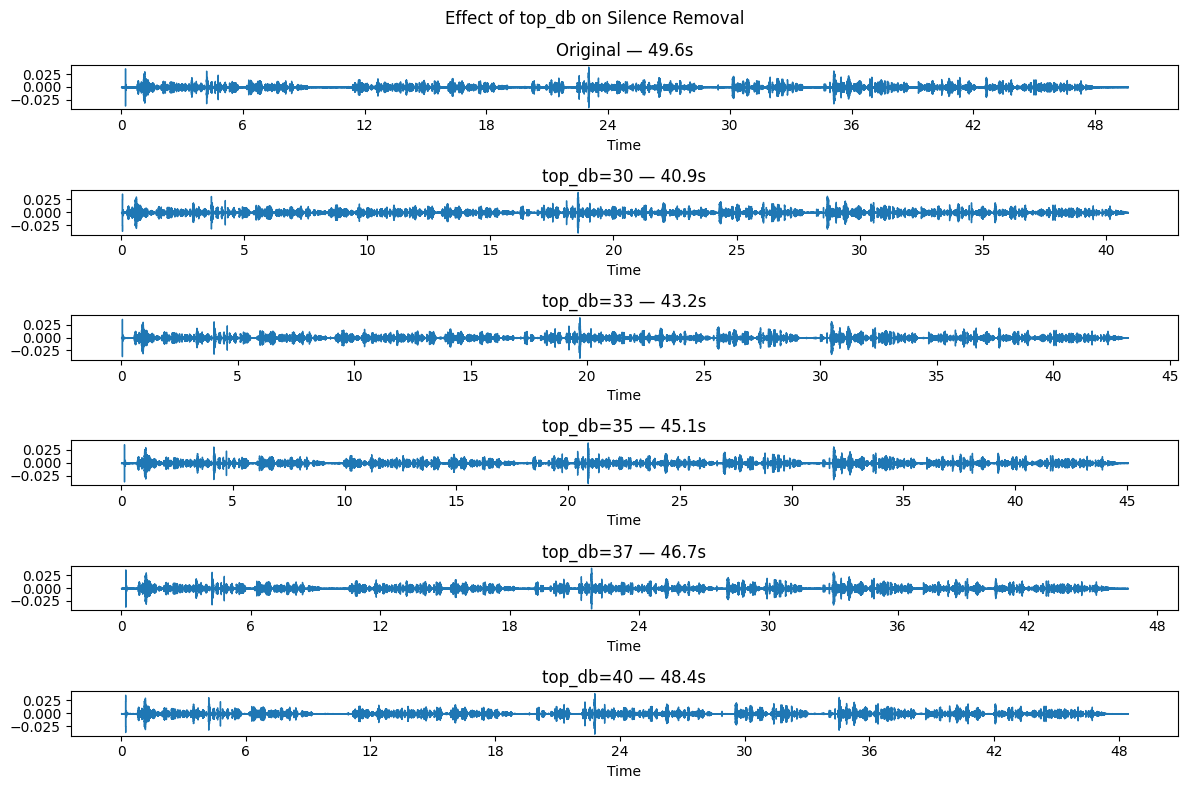

In [5]:
def compare_top_db(audio_raw, sr, top_db_values=[30, 33, 35, 37, 40]):
    fig, axes = plt.subplots(len(top_db_values) + 1, 1, figsize=(12, 8))
    fig.suptitle("Effect of top_db on Silence Removal")

    # Plot original
    librosa.display.waveshow(audio_raw, sr=sr, ax=axes[0])
    axes[0].set_title(f"Original — {len(audio_raw)/sr:.1f}s")

    for i, top_db in enumerate(top_db_values):
        intervals = librosa.effects.split(audio_raw, top_db=top_db)
        # print("Intervals:", intervals)
        audio_trimmed = np.concatenate([audio_raw[s:e] for s, e in intervals])

        librosa.display.waveshow(audio_trimmed, sr=sr, ax=axes[i + 1])
        axes[i + 1].set_title(f"top_db={top_db} — {len(audio_trimmed)/sr:.1f}s")

    plt.tight_layout()
    plt.savefig("images/silence_removal_analysis.png", dpi=150)
    plt.show()

compare_top_db(audio_raw=audio, sr=sample_rate)

Remove comments to play trimmed audio.

In [6]:
intervals = librosa.effects.split(audio, top_db=30)
audio_trimmed = np.concatenate([audio[s:e] for s, e in intervals])

print(f"Sample rate: {sample_rate} Hz")
print(f"Duration: {len(audio_trimmed)/sample_rate:.2f}s")
print(f"Shape: {audio_trimmed.shape}")

# print("Playing trimmed audio...")
# sd.play(audio_trimmed, sample_rate)
# sd.wait()

Sample rate: 16000 Hz
Duration: 40.90s
Shape: (654336,)


#### Normalisation

Audio normalisation. We normalise the trimmed audio not the original audio.

In [7]:
# peak normalisation: scale so the max absolute value is 1.0
max_val = np.max(np.abs(audio_trimmed))
audio_normalised = audio_trimmed

if max_val > 0:  # avoid division by zero
    audio_normalised = audio_trimmed / max_val

Remove comments to play normalised audio.

In [8]:
print(f"Sample rate: {sample_rate} Hz")
print(f"Duration: {len(audio_normalised)/sample_rate:.2f}s")
print(f"Shape: {audio_normalised.shape}")

# print("Playing normalised audio...")
# sd.play(audio_normalised, sample_rate)
# sd.wait()

Sample rate: 16000 Hz
Duration: 40.90s
Shape: (654336,)


## Core Pipeline

Now that initial experimentation is done, let's implement the core pipeline to create embeddings from all speakers + passages.

### Methods

#### Audio preprocessing

Method to load audio from .wav file, removal silence and normalise

In [9]:
def preprocess_audio(file_path, sr=16000, top_db=30):
    # load and resample to 16kHz mono
    audio, _ = librosa.load(file_path, sr=sr)

    # silence removal
    non_silent_intervals = librosa.effects.split(audio, top_db=top_db)
    audio = np.concatenate([audio[start:end] for start, end in non_silent_intervals])

    # normalisation
    max_val = np.max(np.abs(audio))
    if max_val > 0:  # Avoid division by zero
        audio = audio / max_val

    return audio

#### Get embedding

Method to get embedding from WavLM model.

We use `@torch.no_grad()` as without it PyTorch tracks gradients unnecessarily, wasting memory and time.

In [10]:
@torch.no_grad()
def get_embedding(audio):
    inputs = feature_extractor(audio, sampling_rate=16000, return_tensors="pt")
    embeddings = model(**inputs).embeddings
    embeddings = torch.nn.functional.normalize(embeddings, dim=-1).cpu()
    return embeddings

#### Create embeddings for all speakers & passages

In [11]:
def create_all_embeddings(root_dir):
    embeddings_lst = []
    file_name_a = "shortpassagea_CT.wav"
    file_name_b = "shortpassageb_CT.wav"
    file_name_c = "shortpassagec_CT.wav"

    possible_file_names = {
        file_name_a,
        file_name_b,
        file_name_c
    }
    
    for dir_path, _, file_names in os.walk(root_dir):
        for file_name in file_names:
            if file_name not in possible_file_names:
                print("ALERT! Not generating embedding for file:", file_name)
                continue

            file_path = dir_path + "/" + file_name

            print("Generating embedding for file at location:", file_path)
            audio = preprocess_audio(file_path)
            embedding = get_embedding(audio)

            split_dir = dir_path.split("/")
            entry = {
                "path": file_path,
                "accent": split_dir[3],
                "gender": split_dir[4],
                "speaker_id": split_dir[5],
                "short_passage": file_name,
                "embedding": embedding
            }

            embeddings_lst.append(entry)

            print("-"*20)
    return embeddings_lst

#### Compare all embeddings

We can't only use speaker id but we create the id of the speaker from the accent + gender + speaker id as I discovered that there were two speakers with the same ids which was effecting the metrics.

- `brm_001/male/axm001`
- `roi_001/femaile/axm001`

In [12]:
def compare_all_embeddings(embeddings):
    comparisons = []

    for i, j in combinations(embeddings, 2):
        embedding_one_path = i["path"]
        embedding_one = i["embedding"]
        gender_one = "f" if i["gender"].lower() == "female" else "m"
        speaker_one = f"{i['accent']}_{gender_one}_{i['speaker_id']}"
    
        embedding_two_path = j["path"]    
        embedding_two = j["embedding"]
        gender_two = "f" if j["gender"].lower() == "female" else "m"
        speaker_two = f"{j['accent']}_{gender_two}_{j['speaker_id']}"
    
        same_speaker = speaker_one == speaker_two

        cosine_sim = torch.nn.CosineSimilarity(dim=-1)
        score = cosine_sim(embedding_one, embedding_two)
    
        comparison_entry = {
            "path_one": embedding_one_path,
            "path_two": embedding_two_path,
            "speaker_one": speaker_one,
            "speaker_two": speaker_two,
            "score": float(score[0]),
            "same_speaker": same_speaker   # ground truth label
        }
    
        comparisons.append(comparison_entry)
    
    return comparisons

#### Compare embeddings with different thresholds

Evaluate with different thresholds and print out the threshold that get's the best results.

In [13]:
def evaluate_comparisons(comparisons):
    thresholds = [0.95, 0.96, 0.97, 0.98, 0.99]

    same_speaker_scores = [e["score"] for e in comparisons if e["same_speaker"]]
    different_speaker_scores = [e["score"] for e in comparisons if not e["same_speaker"]]

    print("SAME SPEAKER METRICS:")
    print("Min:", min(same_speaker_scores))
    print("Max:", max(same_speaker_scores))
    print("Avg:", sum(same_speaker_scores) / len(same_speaker_scores))

    print("\nDIFFERENT SPEAKER METRICS:")
    print("Min:", min(different_speaker_scores))
    print("Max:", max(different_speaker_scores))
    print("Avg:", sum(different_speaker_scores) / len(different_speaker_scores))

    print()

    results = []
    
    for threshold in thresholds:
        tp = sum(1 for e in comparisons if e["score"] >= threshold and e["same_speaker"])
        tn = sum(1 for e in comparisons if e["score"] <  threshold and not e["same_speaker"])
        fp = sum(1 for e in comparisons if e["score"] >= threshold and not e["same_speaker"])
        fn = sum(1 for e in comparisons if e["score"] <  threshold and e["same_speaker"])
    
        total = len(comparisons)
        accuracy = (tp + tn) / total
        recall = tp / (tp + fn)
        precision = tp / (tp + fp)
        f1_score = (2 * precision * recall) / (precision + recall)
    
        results.append({
            "threshold": round(threshold, 2),
            "accuracy": accuracy,
            "recall": recall,
            "precision": precision,
            "f1_score": f1_score,
            "tp": tp, "tn": tn, "fp": fp, "fn": fn
        })
    
        print(f"Threshold {threshold:.2f} | Accuracy: {accuracy:.4f} | Recall: {recall:4f} | Precision: {precision:4f} | F1 Score: {f1_score:4f} | TP: {tp} TN: {tn} FP: {fp} FN: {fn}")
    
    return results

### Main

First we create all of the embeddings and then we perform analysis (consine similarity, PCA, etcetera).

#### Create all embeddings

In [14]:
if os.path.exists(EMBEDDINGS_FILE):
    # Load pre-computed embeddings
    print("Loading saved embeddings...")
    all_embeddings = torch.load(EMBEDDINGS_FILE)
else:
    # Compute and save embeddings
    print("Computing embeddings...")
    all_embeddings = create_all_embeddings(datasets_base_dir)
    torch.save(all_embeddings, EMBEDDINGS_FILE)

print("No. of embeddings:", len(all_embeddings))
print("First embedding:", all_embeddings[0])

Loading saved embeddings...
No. of embeddings: 855
First embedding: {'path': 'datasets/abi-1-corpus/accents/brm_001/female/alw001/shortpassagea_CT.wav', 'accent': 'brm_001', 'gender': 'female', 'speaker_id': 'alw001', 'short_passage': 'shortpassagea_CT.wav', 'embedding': tensor([[-0.0170, -0.0113, -0.0145,  0.0249, -0.0089,  0.0355, -0.0305, -0.0108,
         -0.0151, -0.0114, -0.0153, -0.0180, -0.0189, -0.0131, -0.0431, -0.0187,
         -0.0132, -0.0123, -0.0178, -0.0907, -0.0146, -0.0118, -0.0093, -0.0137,
         -0.0106, -0.0148, -0.0166, -0.0188, -0.0117, -0.0301, -0.0129, -0.0103,
         -0.0105, -0.0184, -0.0152, -0.0257,  0.0156, -0.0160, -0.0533, -0.0175,
         -0.0204, -0.0206, -0.0129, -0.0197, -0.0999, -0.0168, -0.0164, -0.0105,
          0.0010, -0.0154, -0.0121, -0.0221, -0.1061, -0.0115, -0.0372, -0.0155,
         -0.0403, -0.0161, -0.0161, -0.0152, -0.0143, -0.0395, -0.0352, -0.0135,
         -0.0464, -0.0156, -0.1179, -0.0146, -0.0110, -0.1509, -0.0157,  0.0042,

#### Compare all embeddings

Generate a score for all of the embeddings pairs.

In [15]:
if os.path.exists(COMPARISONS_FILE):
    # Load pre-computed comparison scores
    print("Loading saved comparisons...")
    comparisons = torch.load(COMPARISONS_FILE)
else:
    # Compute and save scores
    print("Computing comparisons...")
    comparisons = compare_all_embeddings(all_embeddings)
    torch.save(comparisons, COMPARISONS_FILE)

print("No. of comparisons:", len(comparisons))
print("First comparison:", comparisons[0])

Loading saved comparisons...
No. of comparisons: 365085
First comparison: {'path_one': 'datasets/abi-1-corpus/accents/brm_001/female/alw001/shortpassagea_CT.wav', 'path_two': 'datasets/abi-1-corpus/accents/brm_001/female/alw001/shortpassageb_CT.wav', 'speaker_one': 'brm_001_f_alw001', 'speaker_two': 'brm_001_f_alw001', 'score': 0.9927594065666199, 'same_speaker': True}


#### Classify using different thresholds

We select the 0.98 threshold because it has the best accuracy.

In [16]:
results = evaluate_comparisons(comparisons)

chosen = next(r for r in results if r["threshold"] == 0.98)
print(f"\nChosen threshold: {chosen['threshold']}")
print(f"Accuracy: {chosen['accuracy']}")
print(f"Recall: {chosen['recall']}")
print(f"Precision: {chosen['precision']}")
print(f"F1 Score: {chosen['f1_score']}")

SAME SPEAKER METRICS:
Min: 0.9701511263847351
Max: 0.9984488487243652
Avg: 0.9930438710932146

DIFFERENT SPEAKER METRICS:
Min: 0.24212267994880676
Max: 0.9892157912254333
Avg: 0.748936289377046

Threshold 0.95 | Accuracy: 0.9840 | Recall: 1.000000 | Precision: 0.127365 | F1 Score: 0.225951 | TP: 855 TN: 358372 FP: 5858 FN: 0
Threshold 0.96 | Accuracy: 0.9935 | Recall: 1.000000 | Precision: 0.263807 | F1 Score: 0.417480 | TP: 855 TN: 361844 FP: 2386 FN: 0
Threshold 0.97 | Accuracy: 0.9981 | Recall: 1.000000 | Precision: 0.557003 | F1 Score: 0.715481 | TP: 855 TN: 363550 FP: 680 FN: 0
Threshold 0.98 | Accuracy: 0.9997 | Recall: 0.990643 | Precision: 0.896296 | F1 Score: 0.941111 | TP: 847 TN: 364132 FP: 98 FN: 8
Threshold 0.99 | Accuracy: 0.9996 | Recall: 0.838596 | Precision: 1.000000 | F1 Score: 0.912214 | TP: 717 TN: 364230 FP: 0 FN: 138

Chosen threshold: 0.98
Accuracy: 0.9997096566552994
Recall: 0.9906432748538012
Precision: 0.8962962962962963
F1 Score: 0.9411111111111111


#### Confusion Matrix

Print confusion matrix of the results. As can be seen, the model is quite good at identifying the correct speaker.

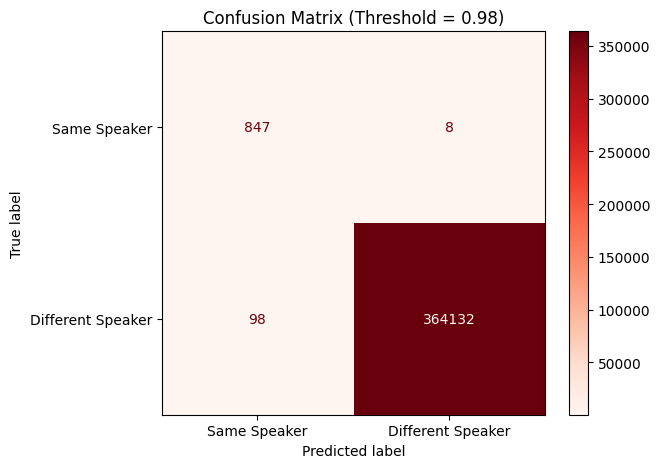

In [17]:
THRESHOLD = chosen["threshold"]

y_true = [1 if e["same_speaker"] else 0 for e in comparisons]
y_pred = [1 if e["score"] >= THRESHOLD else 0 for e in comparisons]

cm = confusion_matrix(y_true, y_pred, labels=[1, 0])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Same Speaker", "Different Speaker"]
)

disp.plot(cmap="Reds")
plt.title(f"Confusion Matrix (Threshold = {THRESHOLD})")
plt.tight_layout()
plt.savefig("images/confusion_matrix.png", dpi=150)
plt.show()

### Further analysis

Let's analyse further.

#### Speaker by speaker

Let's look into the results speaker by speaker.

As can be seen, we achieve perfect speaker identification.

In [18]:
speaker_by_speaker = defaultdict(list)

for e in comparisons:
    if e["speaker_one"] != e["speaker_two"]:
        continue
    speaker_by_speaker[e["speaker_one"]].append(e)

# Evaluate each speaker
speaker_results = {}

for speaker, pairs in speaker_by_speaker.items():
    tp = sum(1 for e in pairs if e["score"] >= THRESHOLD)  # correctly identified as same
    fn = sum(1 for e in pairs if e["score"] < THRESHOLD)   # missed same-speaker pairs
    total = len(pairs)

    recall = tp / total if total > 0 else 0  # how often same-speaker pairs were caught

    speaker_results[speaker] = {
        "tp": tp,
        "fn": fn,
        "total": total,
        "recall": recall,
        "avg_score": sum(e["score"] for e in pairs) / total
    }

for speaker, res in sorted(speaker_results.items(), key=lambda x: x[1]["recall"]):
    print(
        f"{speaker:<15} | "
        f"Recall: {res['recall']:.2f} | "
        f"Avg Score: {res['avg_score']:.4f} | "
        f"TP: {res['tp']} FN: {res['fn']} / {res['total']}"
    )

brm_001_f_mjd001 | Recall: 0.33 | Avg Score: 0.9836 | TP: 1 FN: 2 / 3
lan_001_m_gxb001 | Recall: 0.33 | Avg Score: 0.9794 | TP: 1 FN: 2 / 3
ean_001_m_asp001 | Recall: 0.67 | Avg Score: 0.9842 | TP: 2 FN: 1 / 3
gla_001_f_lna001 | Recall: 0.67 | Avg Score: 0.9858 | TP: 2 FN: 1 / 3
gla_001_m_wht001 | Recall: 0.67 | Avg Score: 0.9862 | TP: 2 FN: 1 / 3
ncl_001_m_krt001 | Recall: 0.67 | Avg Score: 0.9851 | TP: 2 FN: 1 / 3
brm_001_f_alw001 | Recall: 1.00 | Avg Score: 0.9925 | TP: 3 FN: 0 / 3
brm_001_f_cxb001 | Recall: 1.00 | Avg Score: 0.9925 | TP: 3 FN: 0 / 3
brm_001_f_jah001 | Recall: 1.00 | Avg Score: 0.9959 | TP: 3 FN: 0 / 3
brm_001_f_jep001 | Recall: 1.00 | Avg Score: 0.9932 | TP: 3 FN: 0 / 3
brm_001_f_knb001 | Recall: 1.00 | Avg Score: 0.9958 | TP: 3 FN: 0 / 3
brm_001_f_lcg001 | Recall: 1.00 | Avg Score: 0.9944 | TP: 3 FN: 0 / 3
brm_001_f_lst001 | Recall: 1.00 | Avg Score: 0.9941 | TP: 3 FN: 0 / 3
brm_001_f_mpt001 | Recall: 1.00 | Avg Score: 0.9970 | TP: 3 FN: 0 / 3
brm_001_f_rkk001 | R

#### Investigate false positives

Investigate those cases where classifier predicts that two embeddings have the same speaker when in fact they do not.

##### Method to get accent from speaker id

In [19]:
def get_accent(speaker_id):
    return speaker_id.split("_")[0]

##### Method to get gender from speaker id

In [20]:
def get_gender(speaker_id):
    return speaker_id.split("_")[2]

##### Calculate total no. of false positives

In [21]:
false_positives = [
    e for e in comparisons 
    if e["score"] >= THRESHOLD and not e["same_speaker"]
]

print(f"Total False Positives: {len(false_positives)}")

Total False Positives: 98


##### Top confused speaker pairs

In [22]:
fp_pairs = Counter(
    tuple(sorted([e["speaker_one"], e["speaker_two"]]))
    for e in false_positives
)

fp_pairs_top_n = 20

print(f"\nMost confused speaker pairs (top {fp_pairs_top_n}):")
for (spk1, spk2), count in fp_pairs.most_common(fp_pairs_top_n):
    print(f"  {spk1} <-> {spk2} : {count} times")


Most confused speaker pairs (top 20):
  ean_001_f_cxb002 <-> lvp_001_f_jrk001 : 8 times
  eyk_001_f_tlr001 <-> sse_001_f_nta001 : 8 times
  ean_001_f_cxb002 <-> eyk_001_f_tlr001 : 7 times
  crn_001_f_slm001 <-> eyk_001_f_tlr001 : 6 times
  eyk_001_f_sjf001 <-> lvp_001_f_eah001 : 6 times
  nwa_001_f_bea001 <-> nwa_001_f_lrc001 : 6 times
  brm_001_f_mpt001 <-> nwa_001_f_sxt001 : 4 times
  ilo_001_f_jxo001 <-> ilo_001_f_rlg001 : 4 times
  crn_001_f_exc001 <-> nwa_001_f_paj001 : 3 times
  crn_001_f_lms002 <-> nwa_001_f_bea001 : 3 times
  ean_001_f_ald001 <-> lvp_001_f_jxh001 : 3 times
  ean_001_f_jkb001 <-> ean_001_f_ljb001 : 3 times
  eyk_001_f_svj001 <-> lan_001_f_acf001 : 3 times
  lvp_001_f_eah001 <-> lvp_001_f_klm001 : 3 times
  sse_001_f_gke001 <-> sse_001_f_nta001 : 3 times
  crn_001_f_jmc003 <-> eyk_001_f_sxc002 : 2 times
  ean_001_f_dab001 <-> ilo_001_f_jrg001 : 2 times
  ean_001_f_rxt001 <-> ilo_001_f_seg001 : 2 times
  eyk_001_f_tlr001 <-> lvp_001_f_jrk001 : 2 times
  eyk_001_f

##### False positives within vs. across accents

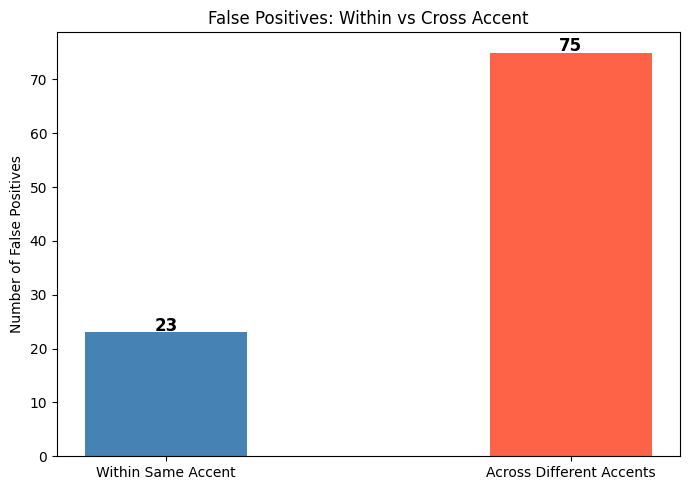

In [23]:
within_accent_fp = [
    e for e in false_positives
    if get_accent(e["speaker_one"]) == get_accent(e["speaker_two"])
]
cross_accent_fp = [
    e for e in false_positives
    if get_accent(e["speaker_one"]) != get_accent(e["speaker_two"])
]

labels = ["Within Same Accent", "Across Different Accents"]
counts = [len(within_accent_fp), len(cross_accent_fp)]
colors = ["steelblue", "tomato"]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, counts, color=colors, width=0.4)

# Add count labels on top of each bar
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(count),
        ha="center", fontsize=12, fontweight="bold"
    )

plt.ylabel("Number of False Positives")
plt.title("False Positives: Within vs Cross Accent")
plt.tight_layout()
plt.savefig("images/fp_within_vs_cross_accent.png", dpi=150)
plt.show()

##### False positives by accent

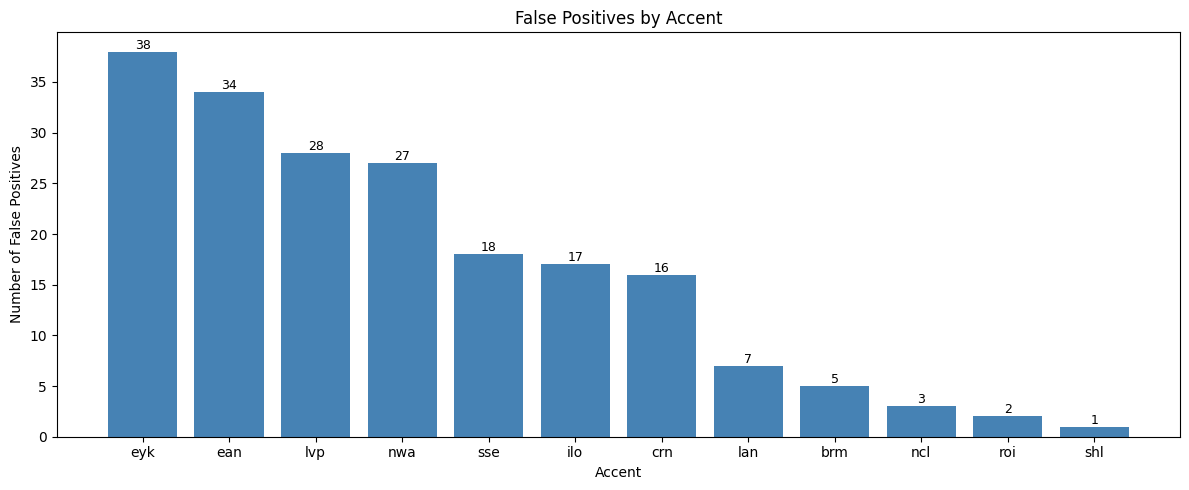

In [24]:
accent_fp_counter = Counter()
for e in false_positives:
    accent_fp_counter[get_accent(e["speaker_one"])] += 1
    accent_fp_counter[get_accent(e["speaker_two"])] += 1

accents, counts = zip(*accent_fp_counter.most_common())

plt.figure(figsize=(12, 5))
bars = plt.bar(accents, counts, color="steelblue")

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(count),
        ha="center", fontsize=9
    )

plt.xlabel("Accent")
plt.ylabel("Number of False Positives")
plt.title("False Positives by Accent")
plt.tight_layout()
plt.savefig("images/fp_by_accent_barchart.png", dpi=150)
plt.show()

##### False positives by accent pair

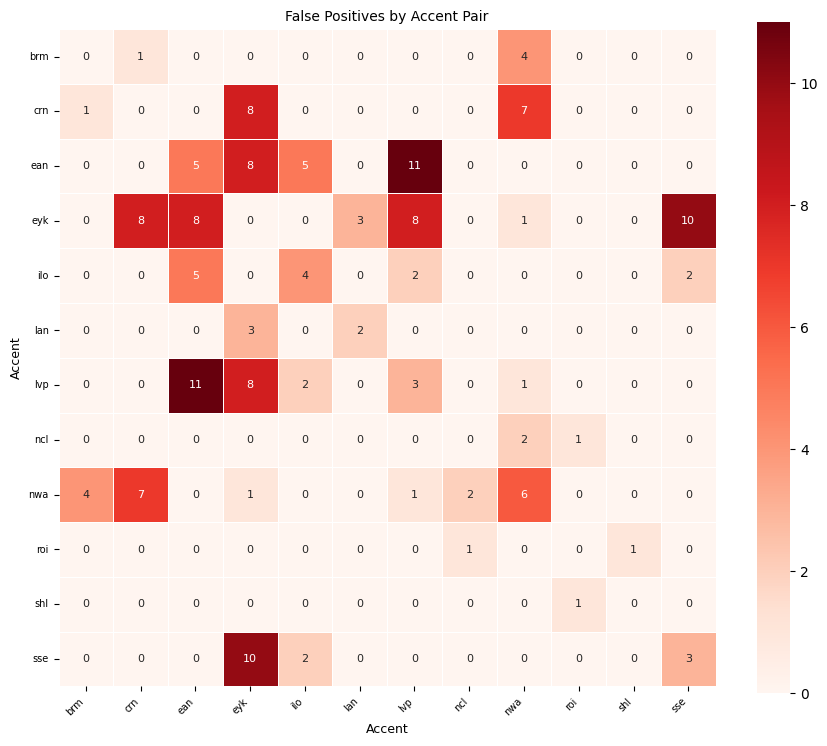

In [25]:
accent_pair_counter = Counter(
    tuple(sorted([get_accent(e["speaker_one"]), get_accent(e["speaker_two"])]))
    for e in false_positives
)

all_accents = sorted(set(
    a for pair in accent_pair_counter for a in pair
))

matrix = np.zeros((len(all_accents), len(all_accents)), dtype=int)
accent_index = {a: i for i, a in enumerate(all_accents)}

for (a1, a2), count in accent_pair_counter.items():
    i, j = accent_index[a1], accent_index[a2]
    matrix[i][j] = count
    matrix[j][i] = count

plt.figure(figsize=(9, 7.5))
sns.heatmap(
    matrix,
    xticklabels=all_accents,
    yticklabels=all_accents,
    annot=True,
    fmt="d",
    cmap="Reds",
    linewidths=0.5,
    square=True,
    annot_kws={"size": 8},
)

plt.title("False Positives by Accent Pair", fontsize=10)
plt.xlabel("Accent", fontsize=9)
plt.ylabel("Accent", fontsize=9)
plt.xticks(fontsize=7, rotation=45, ha="right")
plt.yticks(fontsize=7, rotation=0)
plt.tight_layout()
plt.savefig("images/fp_by_accent_pair_heatmap.png", dpi=150)
plt.show()

##### False positives by gender pairs

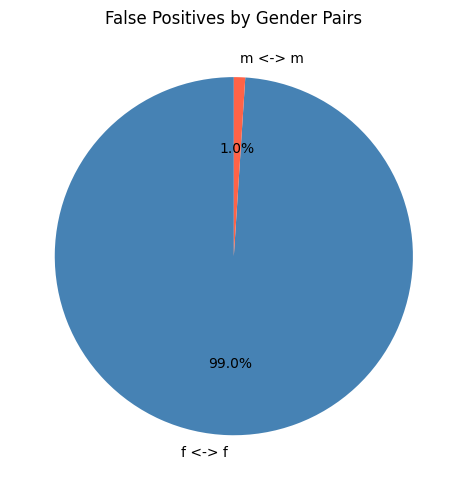

In [26]:
gender_pair_counter = Counter(
    tuple(sorted([get_gender(e["speaker_one"]), get_gender(e["speaker_two"])]))
    for e in false_positives
)
top_pairs = gender_pair_counter.most_common()

labels = [f"{g1} <-> {g2}" for (g1, g2), _ in top_pairs]
counts = [count for _, count in top_pairs]
colors = ["steelblue", "tomato", "mediumpurple"]

plt.figure(figsize=(6, 5))
plt.pie(
    counts,
    labels=labels,
    colors=colors[:len(counts)],
    autopct="%1.1f%%",  # show percentage in each slice
    startangle=90
)

plt.title("False Positives by Gender Pairs")
plt.tight_layout()
plt.savefig("images/fp_by_gender_pair_piechart.png", dpi=150)
plt.show()

#### t-SNE & PCA Preparation

Prepare attributes and methods for t-SNE and PCA.

In [56]:
embeddings_array = np.array([d["embedding"] for d in all_embeddings]).squeeze(axis=1)
labels_speaker   = np.array([d["speaker_id"] for d in all_embeddings])
labels_gender    = np.array([d["gender"] for d in all_embeddings])
labels_accent    = np.array([d["accent"] for d in all_embeddings])

In [57]:
def plot_reduction(embeddings, labels, title, method="tsne", perplexity=30):
    # reduce to 2 dimensions
    n_components = 2

    if method == "tsne":
        reducer = TSNE(n_components=n_components, perplexity=perplexity, random_state=42, max_iter=1000)
    else:
        reducer = PCA(n_components=n_components)

    reduced = reducer.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    unique_labels = np.unique(labels)
    colors = plt.colormaps["tab20"].resampled(len(unique_labels))

    for i, label in enumerate(unique_labels):
        idx = np.where(labels == label)
        plt.scatter(reduced[idx, 0], reduced[idx, 1],
                    label=label, s=50, color=colors(i), alpha=0.8)

    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.savefig(f"images/{title.replace(' ', '_').lower()}.png", dpi=150)
    plt.show()

#### TSNE & PCA on Male vs. Female

Perform analysis on male vs female on the whole dataset.

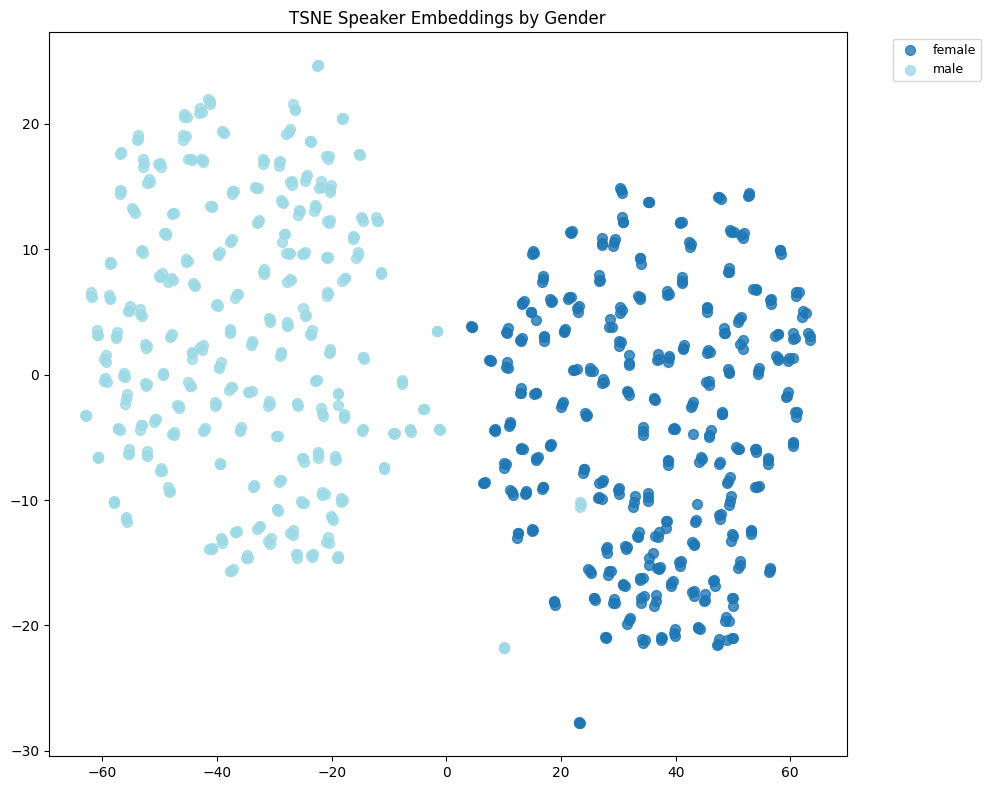

In [58]:
plot_reduction(
    embeddings=embeddings_array,
    labels=labels_gender,
    title="TSNE Speaker Embeddings by Gender",
    method="tsne",
    perplexity=30
)

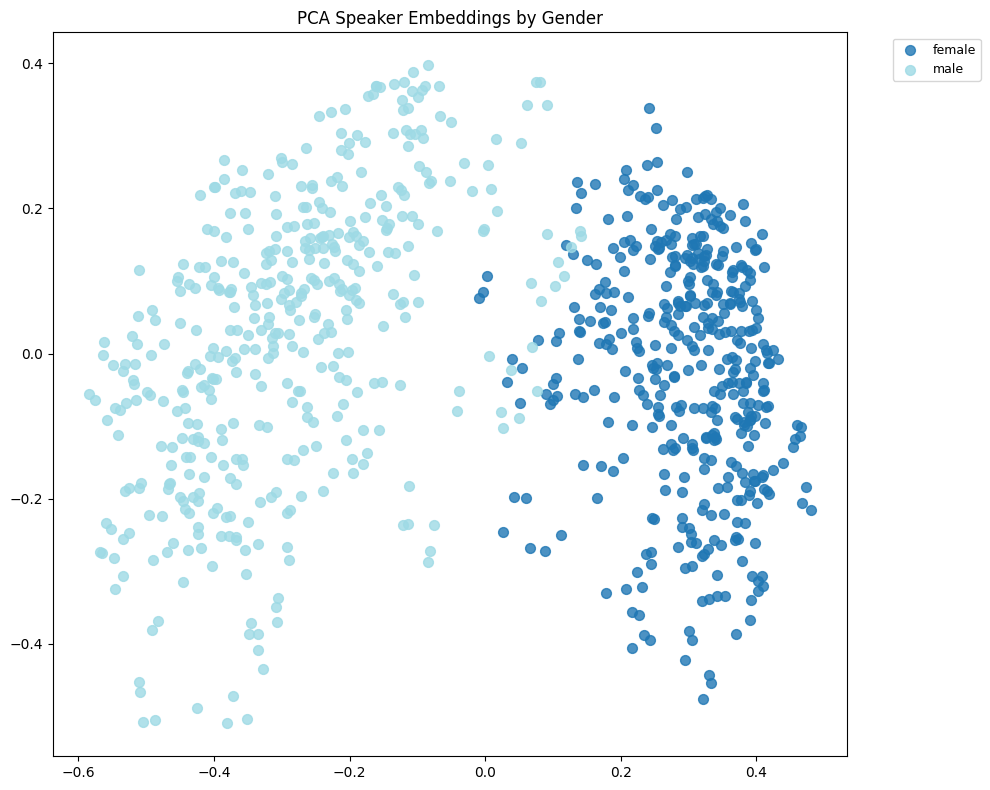

In [59]:
plot_reduction(
    embeddings=embeddings_array,
    labels=labels_gender,
    title="PCA Speaker Embeddings by Gender",
    method="pca",
)

#### TSNE & PCA on `lvp` and `ean` accents

Compared together, these were the two accents that had the most mismatches (as seen in the heatmap).

In [70]:
lvp_ean_comparison_mask = [True if e in {"lvp_001", "ean_001"} else False for e in labels_accent]

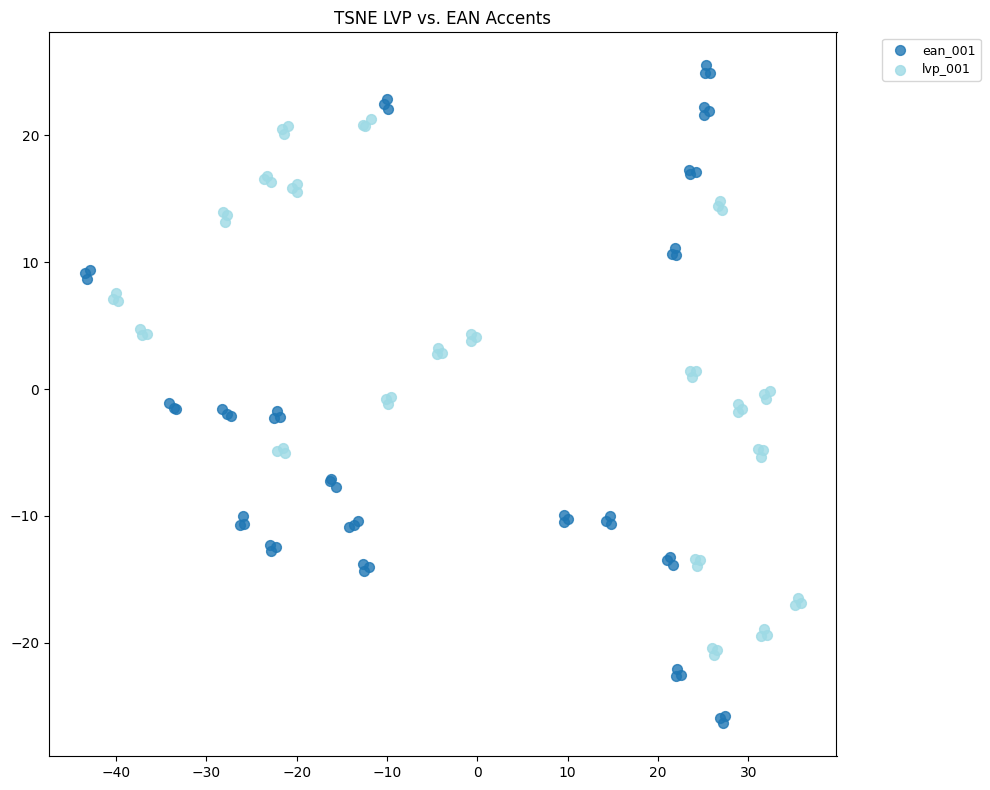

In [67]:
plot_reduction(
    embeddings=embeddings_array[lvp_ean_comparison_mask],
    labels=labels_accent[lvp_ean_comparison_mask],
    title="TSNE LVP vs. EAN Accents",
    method="tsne",
    perplexity=5
)

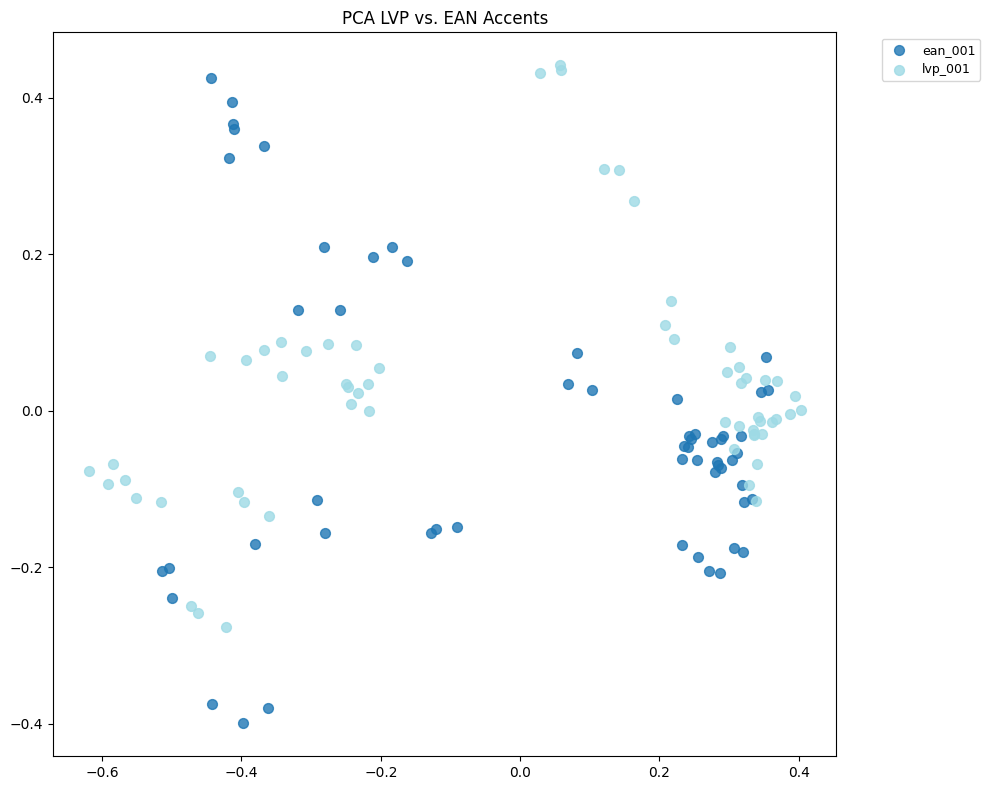

In [69]:
plot_reduction(
    embeddings=embeddings_array[lvp_ean_comparison_mask],
    labels=labels_accent[lvp_ean_comparison_mask],
    title="PCA LVP vs. EAN Accents",
    method="pca",
    perplexity=5
)

#### TSNE & PCA on `ean` accent

Perform analysis on all of the speakers inside the `eyk` accent as this is the accent that is involved in a lot of mismatches with other speakers in the same accent.

In [54]:
ean_mask = labels_accent == "ean_001"

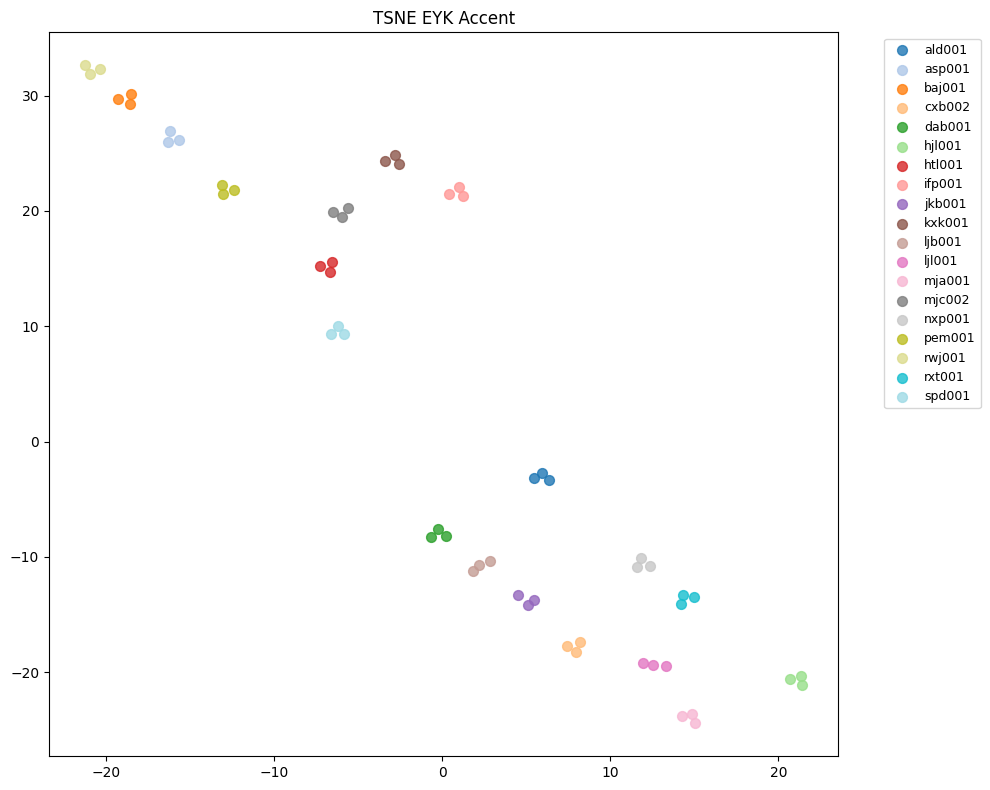

In [71]:
plot_reduction(
    embeddings=embeddings_array[ean_mask],
    labels=labels_speaker[ean_mask],
    title="TSNE EAN Accent",
    method="tsne",
    perplexity=5
)

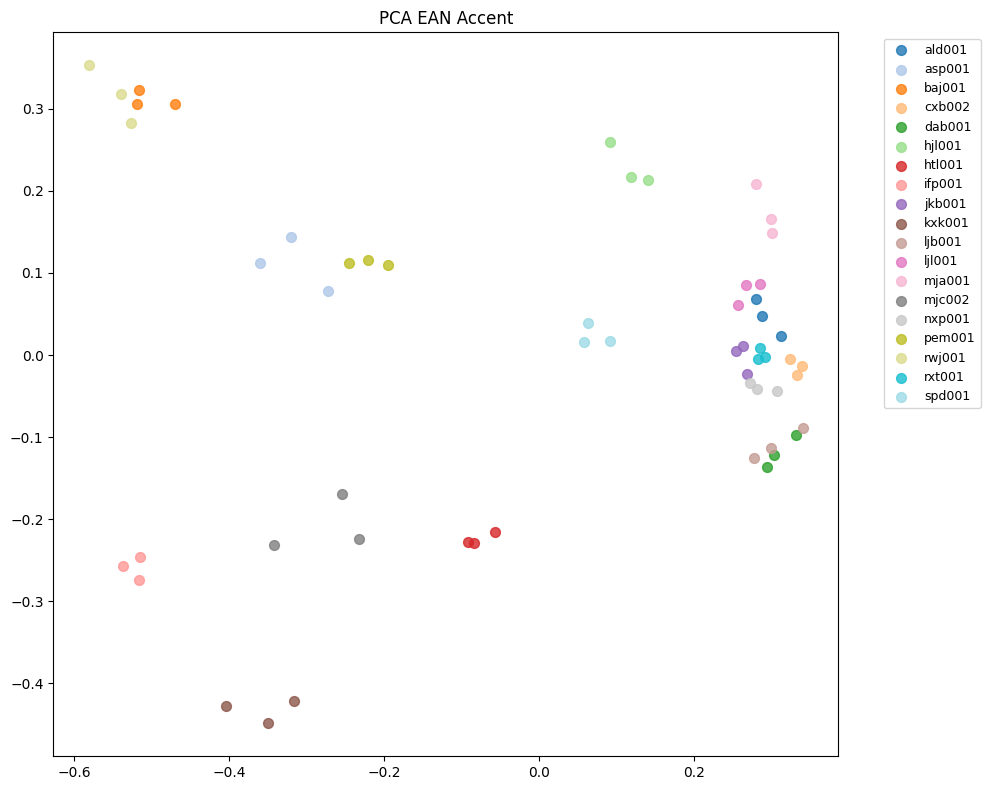

In [72]:
plot_reduction(
    embeddings=embeddings_array[ean_mask],
    labels=labels_speaker[ean_mask],
    title="PCA EAN Accent",
    method="pca",
)

#### TSNE & PCA on `gla` accent

Perform analysis on all of the speakers inside the `gla` accent as this is the accent that is involved in no mismatches.

In [73]:
gla_mask = labels_accent == "gla_001"

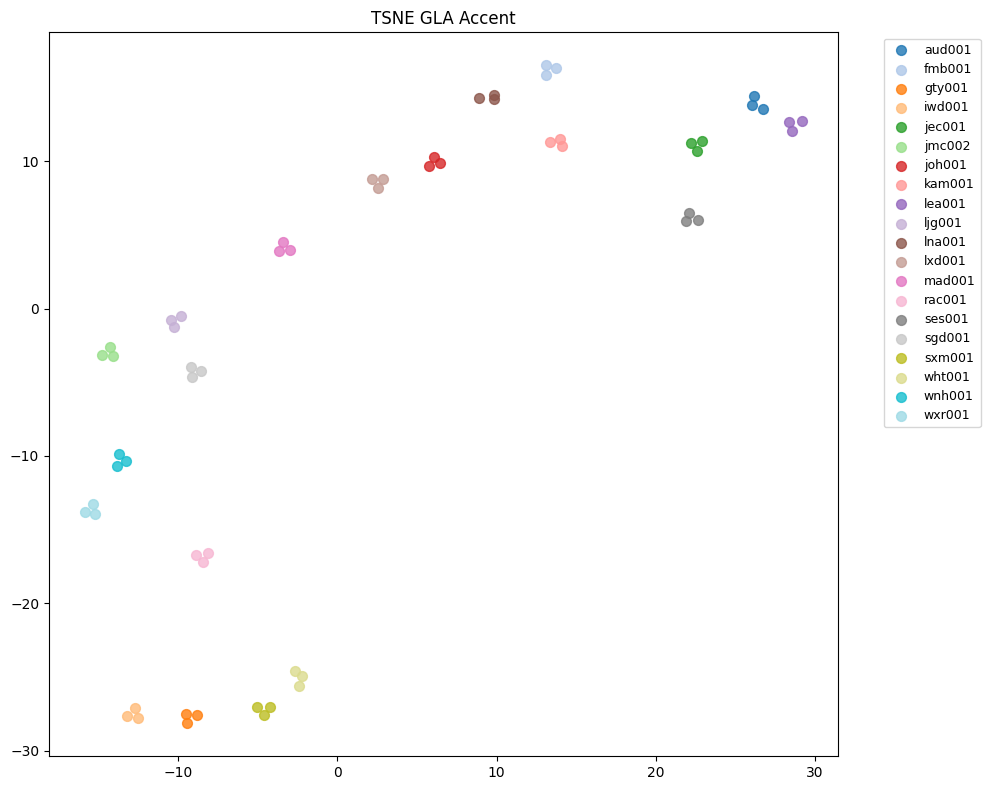

In [75]:
plot_reduction(
    embeddings=embeddings_array[gla_mask],
    labels=labels_speaker[gla_mask],
    title="TSNE GLA Accent",
    method="tsne",
    perplexity=5
)

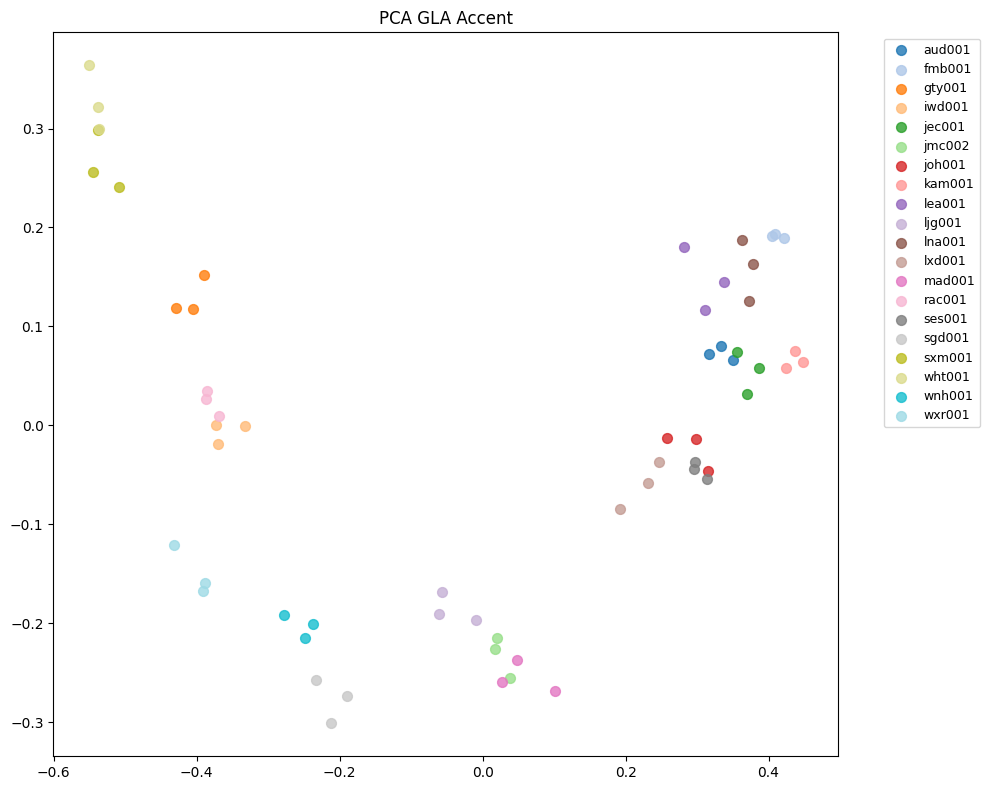

In [76]:
plot_reduction(
    embeddings=embeddings_array[gla_mask],
    labels=labels_speaker[gla_mask],
    title="PCA GLA Accent",
    method="pca",
)